# Exercise 2: Boosting

## Do not start the exercise until you fully understand the submission guidelines.


* The homework assignments are executed automatically. 
* Failure to comply with the following instructions will result in a significant penalty. 
* Appeals regarding your failure to read these instructions will be denied. 
* Kind reminder: the homework assignments contribute 60% of the final grade.


## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your group number and ID as the file name. For example, `hw2_13_123456789_987654321.zip` if you submitted in pairs and `hw2_13_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.
   
Please use only a **zip** file in your submission.

---
---

## Please sign that you have read and understood the instructions: 

### *** YOUR RUNI EMAILS HERE ***

---
---


In [6]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Design your algorithm
Make sure to describe the algorithm, its limitations, and describe use-cases.

AdaBoost uses exponential loss $L(H) = \sum_{i=1}^{n}{ \exp(-y_i \cdot H(x_i))}$ where $y_i \in \{-1, +1\}$  (binary classifer).

We build the ensemble classifer by $H_{t+1} = H_t + \alpha h$, where $h$ is a weak learner of a  decision tree of depth 1 with $\alpha$ impact.
So $L(H_{t+1}) = \sum_{i=1}^{n} \exp(-y_i (H_t(x_i) + \alpha h(x_i))) = \sum_{i=1}^{n} \exp(-y_i H_t(x_i)) \cdot \exp(-y_i \alpha h(x_i))$
Let $w_i = \exp(-y_i H_t(x_i))$ So $$L(H_{t+1}) = \sum_{i=1}^{n} w_i \exp(-y_i \alpha h(x_i))$$

So the error term is $$\epsilon_t = \frac{\sum_{i=1}^{n} w_i \mathbb{I}(y_i \neq h(x_i))}{\sum_{i=1}^{n} w_i}$$
So after rearranging terms: $$\alpha_t = \frac{1}{2} \ln(\frac{1 - \epsilon_t}{\epsilon_t})$$

So have update rule:$$w_{i}^{(t+1)} = w_i^{(t)} \cdot \exp(-\alpha_t \cdot y_i \cdot h(x_i))$$

Normalizing all $w_i $

We will keep updating the model with new weak learners until the number of weak learners passes some threshold or unable to get weak learner with error < 0.5. Each weak learner will be picked by the split that reduces the error rate of the entire ensemble learning .

Algorithm:
Intially set all $w_i = 1/m$ for all data points.
Determine next best weak learner by looping through all feature splits
Calculate its $\alpha$ and update $H_{t+1}$
Keep updating until reach number of weak learners or unable to find good enough weak learner. 

predict by $H(x)$ sign.


Therefore hyperparameters are 
- Number of weak learners (stumps)
- ? learning rate shrinkage factor?

Limitations:
- Training can't be parallelized as is sequential in construction
-  Sensitivity to outliers due to exponential loss which leads to larger weight


Use cases:
- Binary classifcation
- ...



# Your implementations
You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.

In [7]:
import numpy as np

class AdaBoostCustom:
    def __init__(self, T):
        self.T = T
        self.alphas = []
        self.models = []

    def _best_stump(self, X, y, w):
        n_samples, n_features = X.shape
        best_err = float('inf')
        best_feat, best_thresh, best_pol, best_is_cat = None, None, None, None

        for feat in range(n_features):
            col = X[:, feat]
            try:
                col.astype(float)
                is_categorical = False
            except (ValueError, TypeError):
                is_categorical = True

            potential_threshold = np.unique(col)

            for cand in potential_threshold:
                if is_categorical:
                    preds = np.where(col == cand, +1, -1)
                else:
                    preds = np.where(col.astype(float) <= float(cand), +1, -1)
                err = np.sum(w[preds != y]) / np.sum(w)

                if err > 0.5:
                    err = 1 - err
                    polarity = -1
                else:
                    polarity = +1

                if err < best_err:
                    best_err   = err
                    best_feat  = feat
                    best_thresh = cand
                    best_pol   = polarity
                    best_is_cat = is_categorical

        return best_feat, best_thresh, best_pol, best_is_cat, best_err

    def _stump_predict(self, X, model):
        feat, thresh, polarity, is_categorical = model
        col = X[:, feat]
        if is_categorical:
            return np.where(col == thresh, polarity, -polarity)
        else:
            return np.where(col.astype(float) <= float(thresh), polarity, -polarity)

    def fit(self, X, y, categorical_features=None):
        X = np.array(X, dtype=object)
        y = np.array(y, dtype=float)
        n, d = X.shape

        w = np.full(n, 1.0 / n)

        for t in range(self.T):
            feat, thresh, polarity, is_cat, eps = self._best_stump(X, y, w)

            if eps >= 0.5:
                break

            eps   = max(eps, 1e-10)
            alpha = 0.5 * np.log((1.0 - eps) / eps)

            model = (feat, thresh, polarity, is_cat)
            self.models.append(model)
            self.alphas.append(alpha)

            preds = self._stump_predict(X, model)
            w = w * np.exp(-alpha * y * preds)
            w /= w.sum()

    def predict(self, X):
        X = np.array(X, dtype=object)
        H = sum(
            alpha * self._stump_predict(X, model)
            for alpha, model in zip(self.alphas, self.models)
        )
        return np.sign(H)

# Generate data
Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.

The make_moons dataset from sklearn will indicate the effectiveness and correct implentation of the AdaBoost algorithm. This is because the data is inherently non-linear so regular learners and weak learners will struggle but with AdaBoost creating stumps each stump will achieve error rate below 50% but with all of them combined a much higher accuracy should be achievable.

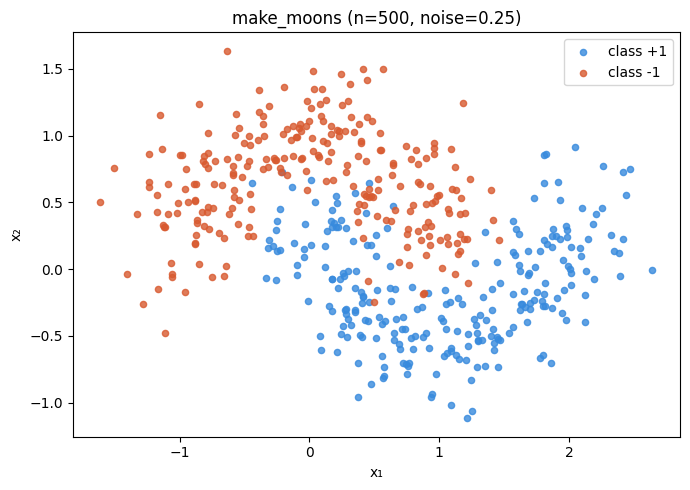

In [8]:
# Your code here
#XOR dataset 
np.random.seed(42)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
y = np.where(y == 0, -1, +1)


plt.figure(figsize=(7, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#378ADD', s=20, label='class +1', alpha=0.8)
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='#D85A30', s=20, label='class -1', alpha=0.8)
plt.legend()
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('make_moons (n=500, noise=0.25)')
plt.tight_layout()
plt.show()


# AdaBoost demonstration 
Demonstrate your AdaBoost implementation.

Add plots and figures. 

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the sklearn implementation. Hint: you can look at the documentation.

Custom  accuracy: 0.88
Sklearn accuracy: 0.87


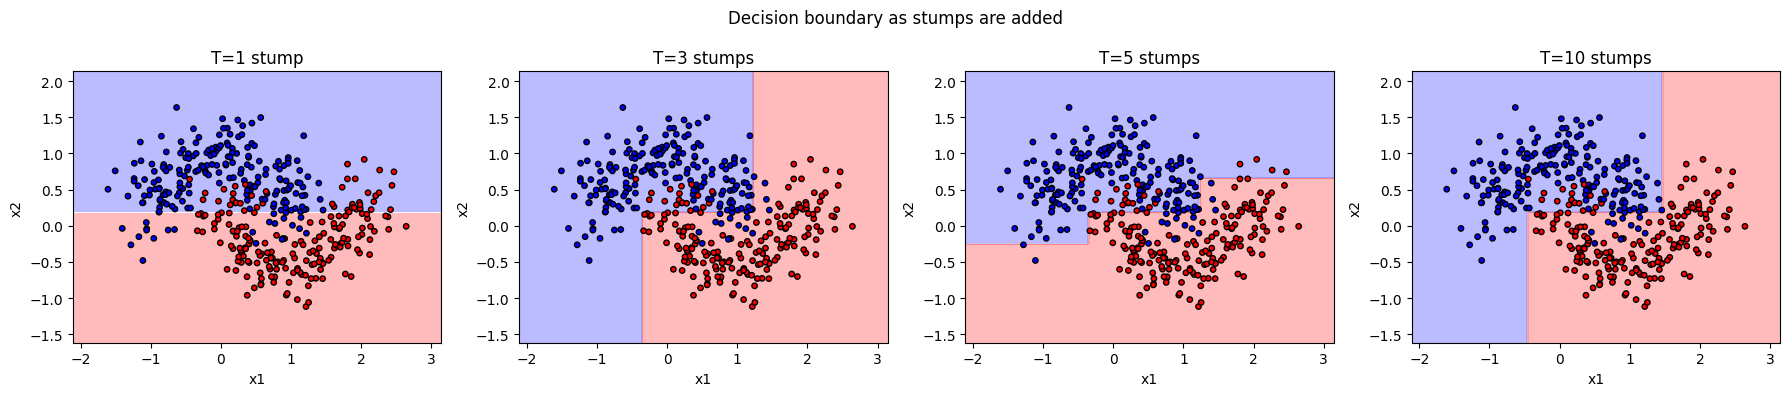

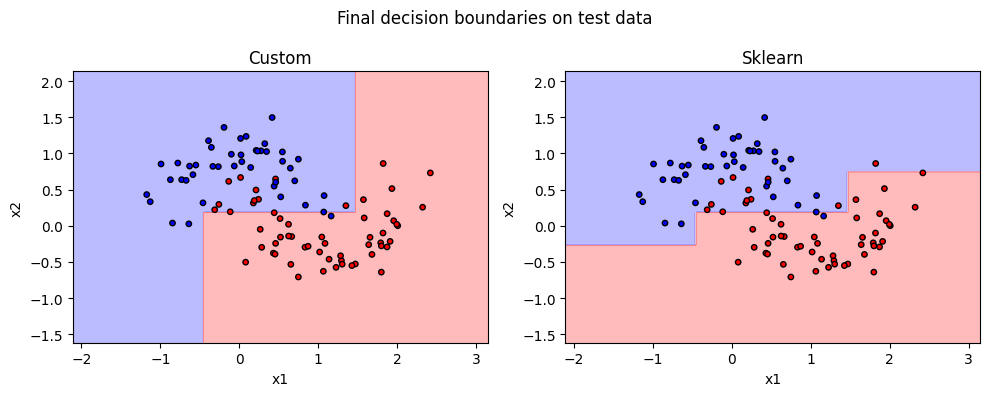

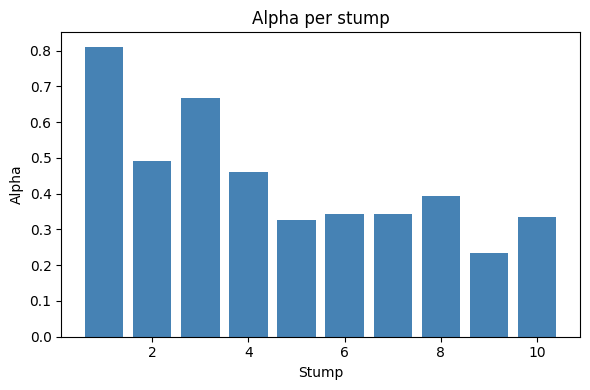

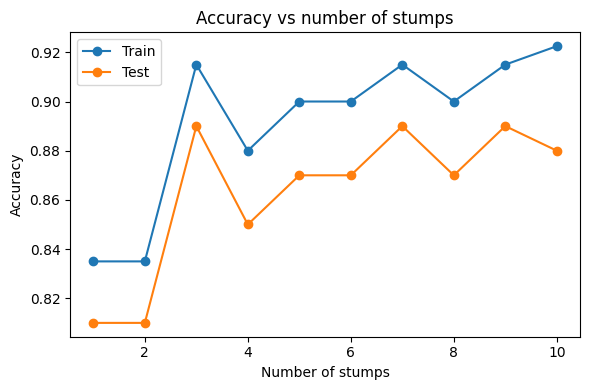

In [9]:
custom_model = AdaBoostCustom(T=10)
sklearn_model = AdaBoostClassifier(n_estimators=10, random_state=42)

# Your code here

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_model.fit(X_train, y_train)
sklearn_model.fit(X_train, np.where(y_train == -1, 0, 1))  


custom_preds  = custom_model.predict(X_test)
sklearn_preds = np.where(sklearn_model.predict(X_test) == 0, -1, 1)

print(f"Custom  accuracy: {accuracy_score(y_test, custom_preds)}")
print(f"Sklearn accuracy: {accuracy_score(y_test, sklearn_preds)}")

# Create meshgrid for decision boundary plots
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Stumps over time 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Decision boundary as stumps are added")
for ax, t in zip(axes, [1, 3, 5, 10]):
    H = sum(
        alpha * custom_model._stump_predict(grid, m)
        for alpha, m in zip(custom_model.alphas[:t], custom_model.models[:t])
    )
    ax.contourf(xx, yy, np.sign(H).reshape(xx.shape), alpha=0.3, cmap='bwr')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(f"T={t} stump{'s' if t > 1 else ''}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

#sklearn vs custom final boundary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Final decision boundaries on test data")

custom_zz  = custom_model.predict(grid).reshape(xx.shape)
sklearn_zz = np.where(sklearn_model.predict(grid) == 0, -1, 1).reshape(xx.shape)

for ax, zz, title in zip(axes, [custom_zz, sklearn_zz], ["Custom", "Sklearn"]):
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='bwr')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

#alpha per stump 
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(custom_model.alphas) + 1), custom_model.alphas, color='steelblue')
plt.title("Alpha per stump")
plt.xlabel("Stump")
plt.ylabel("Alpha")
plt.tight_layout()
plt.show()

# T over time accuracy 
train_accs, test_accs = [], []
for t in range(1, len(custom_model.alphas) + 1):
    H_train = sum(a * custom_model._stump_predict(X_train, m)
                  for a, m in zip(custom_model.alphas[:t], custom_model.models[:t]))
    H_test  = sum(a * custom_model._stump_predict(X_test, m)
                  for a, m in zip(custom_model.alphas[:t], custom_model.models[:t]))
    train_accs.append(accuracy_score(y_train, np.sign(H_train)))
    test_accs.append(accuracy_score(y_test,  np.sign(H_test)))

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train', marker='o')
plt.plot(range(1, len(test_accs)  + 1), test_accs,  label='Test',  marker='o')
plt.title("Accuracy vs number of stumps")
plt.xlabel("Number of stumps")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Results and Comparison with sklearn

Our custom AdaBoost achieves **88% accuracy** on the test set, while sklearn's `AdaBoostClassifier` achieves **87%**. The near-identical performance validates the correctness of our implementation.

### Key differences between our implementation and sklearn's AdaBoostClassifier:

- **Boosting variant**: Our implementation uses classic discrete AdaBoost (SAMME), which relies on hard class predictions from each weak learner. Sklearn defaults to SAMME.R, a real-valued variant that uses the full class probability estimates from weak learners, generally converging faster.
- **Weak learner**: We use a custom decision stump that exhaustively searches all unique feature thresholds to minimize weighted error. Sklearn uses `DecisionTreeClassifier(max_depth=1)` which optimizes Gini impurity and natively supports sample weights.
- **Multi-class support**: Our implementation is binary only ($y \in \{-1, +1\}$). Sklearn supports multi-class classification via both SAMME and SAMME.R.
- **Learning rate**: We do not implement a learning rate (equivalent to `learning_rate=1`). Sklearn provides a configurable `learning_rate` parameter that shrinks $\alpha_t$ each round, trading off the number of estimators against each one's individual contribution.
- **Early stopping**: We stop boosting if $\epsilon_t \geq 0.5$ (no useful weak learner found). Sklearn stops if $\epsilon_t \geq 1 - 1/n\_classes$ or if a perfect fit is achieved.

The slight accuracy difference is expected because SAMME.R uses the full probability output of the weak learner rather than just its hard prediction, which generally leads to faster convergence but can behave differently on small ensembles (T=10).

### Plots:
- **Decision boundary evolution** — how the boundary becomes more complex as stumps are added
- **Custom vs sklearn boundaries** — visual confirmation that both produce similar decision regions
- **Alpha per stump** — the weight assigned to each weak learner (higher = more informative stump)
- **Accuracy vs T** — how train/test accuracy improves with more stumps

# Generate additional data sets
Generate at least two experimental datasets with binary labels, designed to demonstrate specific properties of AdaBoost (e.g., handling noise or overfitting).

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

In [10]:
# Generate additional data sets

# Split data sets
#XOR dataset will struggle with 
X = np.random.randn(2000, 2)
y = np.where(X[:, 0] * X[:, 1] > 0, +1, -1)

In [11]:
# Visualize data

# Test algorithms
Test your AdaBoost, a library implementation of AdaBoost and at least two additional models, one of which must be another boosting algorithm on your two datasets.

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

In [12]:
# Set up models 

In [13]:
# Test and visualize

# Use of generative AI
Please use the cell below to describe your use of generative AI in this assignment. 